In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [40]:
#Loading a dataset
df=pd.read_csv("sales_data_with_discounts.csv")
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [42]:
#Numeric columns in dataset
numeric=df.select_dtypes(include=["number"])
numeric

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...
445,2,1300,2600,15.475687,402.367873,2197.632127
446,6,2600,15600,17.057027,2660.896242,12939.103758
447,2,1600,3200,18.965550,606.897606,2593.102394
448,3,1900,5700,16.793014,957.201826,4742.798174


In [44]:
#mean, median, mode, and standard deviation for these columns.
mean=numeric.mean()
median=numeric.median()
mode=numeric.mode().iloc[0]
standard_deviation=numeric.std()
print("Mean:\n",mean,"\n")
print("Medain:\n",median,"\n")
print("Mode:\n",mode,"\n")
print("Standard Deviation:\n",standard_deviation,"\n")

Mean:
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64 

Medain:
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64 

Mode:
 Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64 

Standard Deviation:
 Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64 



## Brief Interpretation of these Statistics

**Volume:**
Average sales volume is approximately 5 units per transaction.The median (4) and mode (3) show that smaller sales are common. A standard deviation of 4.23 indicates wide variation in volumes.

**Avg Price:**
Average price is approximately 10,453, but the median (1,450) and mode (400) are much lower, suggesting a few very high-priced items skew the average. High variability is shown by the large standard deviation (approximately 18,080).

**Total Sales Value:**
Mean sales value is approximately 33,813, while the median (5,700) is much lower, indicating that some large sales inflate the average. The mode (24,300) reflects a common sales value. High spread (approximately 50,535) confirms wide transaction differences.

**Discount Rate (%):**
Average discount rate is 15%, with a median of 16.6%. The most common discount is 5%, and variation is moderate (std approximately 4.22%).

**Discount Amount:**
Average discount amount is approximately 3,346, but the median (989) and mode (69) show most discounts are small, with some large outliers. High variability (approximately 4,510) reflects this.

**Net Sales Value:**
Average net sales value is approximately 30,466, but the median (4,678) and mode (327) are much lower, suggesting most transactions are small while a few very large ones drive up the mean. Standard deviation (approximately 46,359) shows large variation in revenue.

In [47]:
#DATA VISUALIZATION

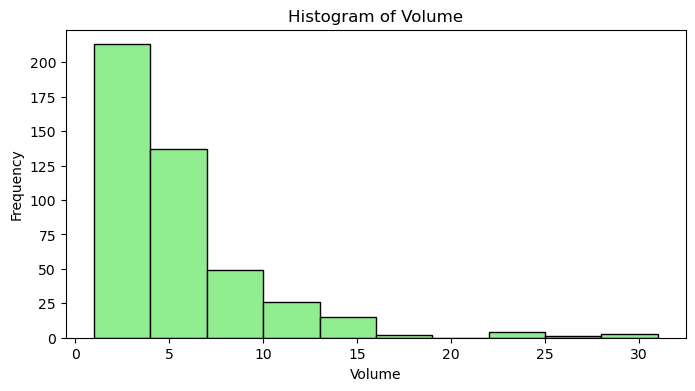

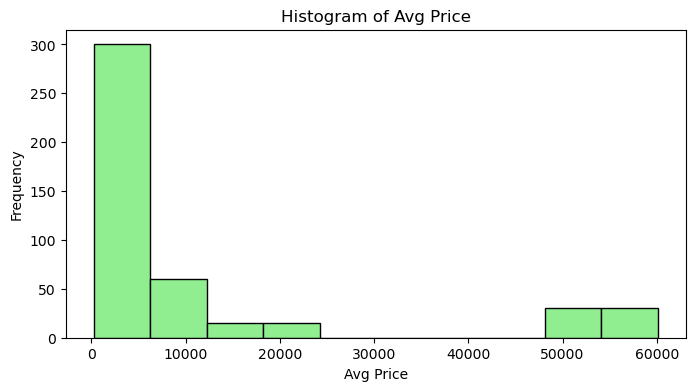

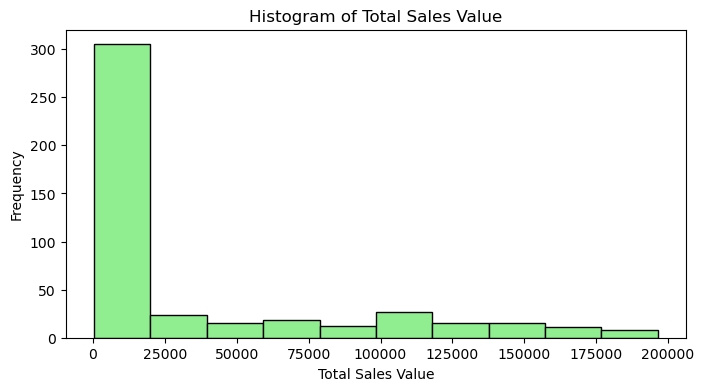

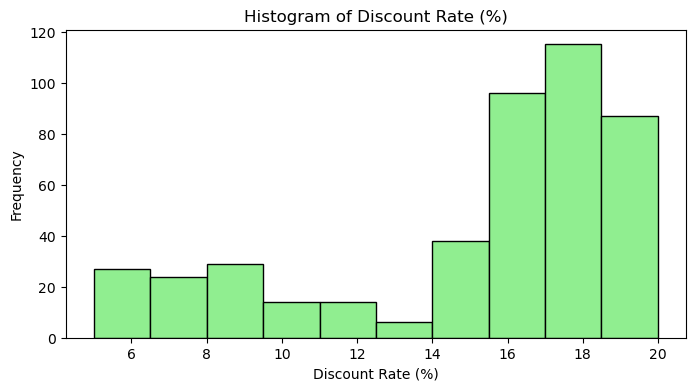

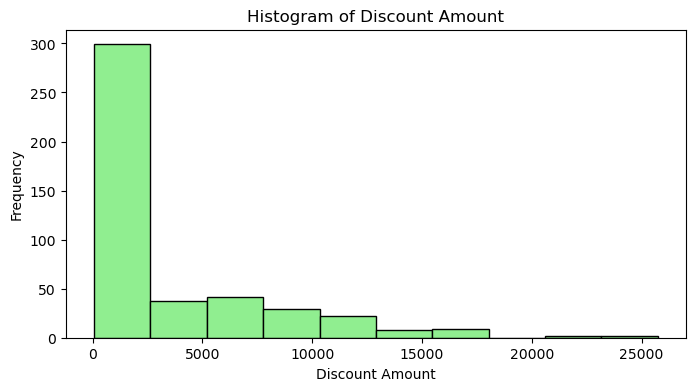

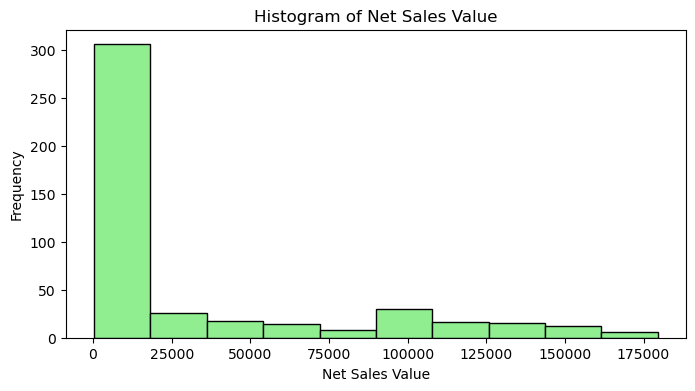

In [49]:
#Histogram for each column
for column in numeric:
    plt.figure(figsize=(8,4))
    plt.hist(df[column], bins=10, color='lightgreen', edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

##	Analyzing the distribution (e.g., skewness, presence of outliers) and provide inferences.

**Volume:**
- Skewness: 2.73 (highly right-skewed)
- Most sales are in small quantities (1–6 units).
- Few large orders (up to 31) act as outliers.

**Avg Price:**
- Skewness: 1.91 (right-skewed)
- Majority of prices are low (under ₹10,000), but a few very high-priced items (up to ₹60,100) push the mean upward.
- Indicates presence of premium models.

**Total Sales Value:**
- Skewness: 1.53 (right-skewed)
- Most transactions are small (below ₹53,200), but few very high-value sales (up to ₹196,400) stretch the distribution.
- Suggests sales spikes from bulk/high-price items.

**Discount Rate (%):**
- Skewness: -1.06 (left-skewed)
- Most discounts cluster between 14–18%, with fewer low discounts (min ~5%).
- Indicates consistent discounting strategy, rarely offering very low discounts.

**Discount Amount:**
- Skewness: 1.91 (right-skewed)
- Many small discounts (<₹5,000), with some very high ones (~₹25,700).
- Larger discounts are tied to bulk or premium sales.

**Net Sales Value:**
- Skewness: 1.54 (right-skewed)
- Most transactions generate <₹50,000 net sales, but some go up to ₹1.8 lakh.
- Shows few high-revenue orders dominate overall sales.

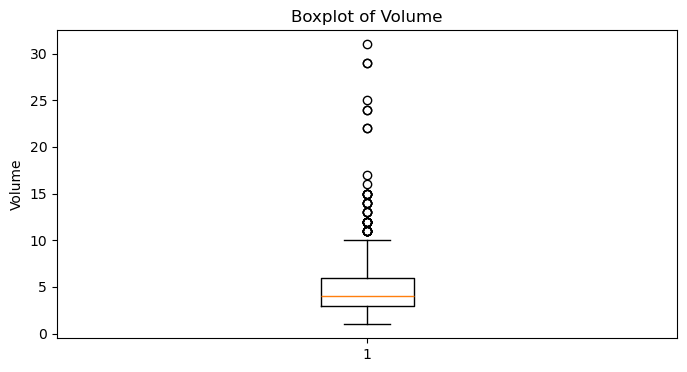

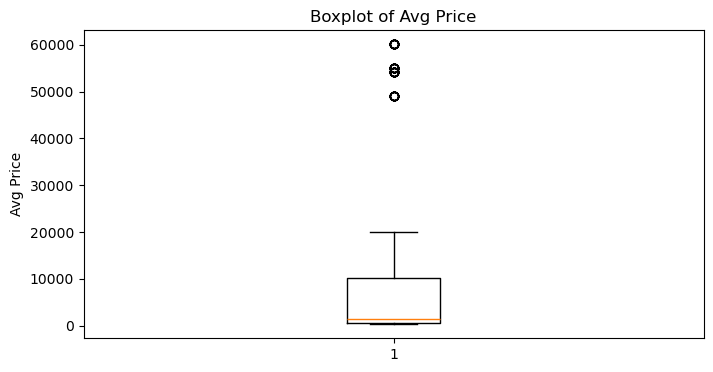

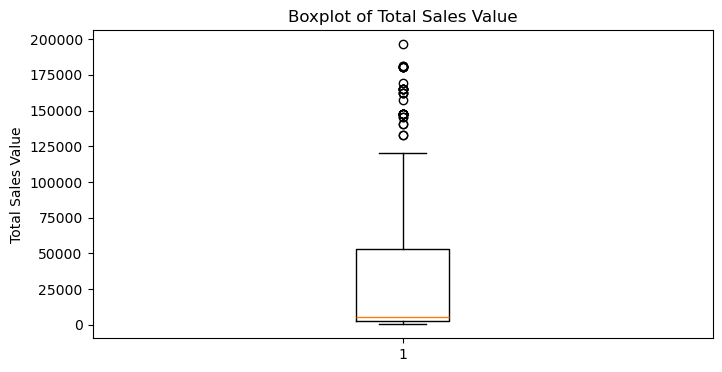

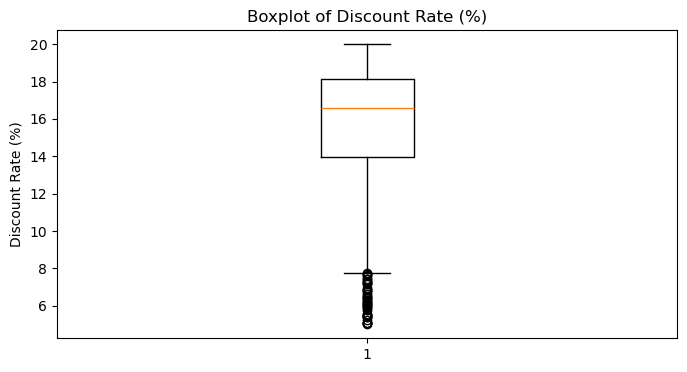

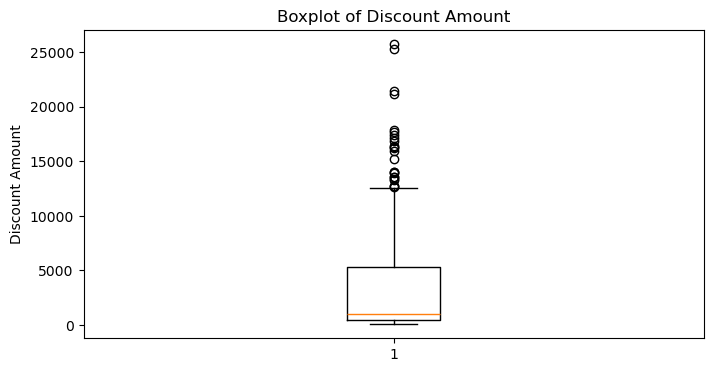

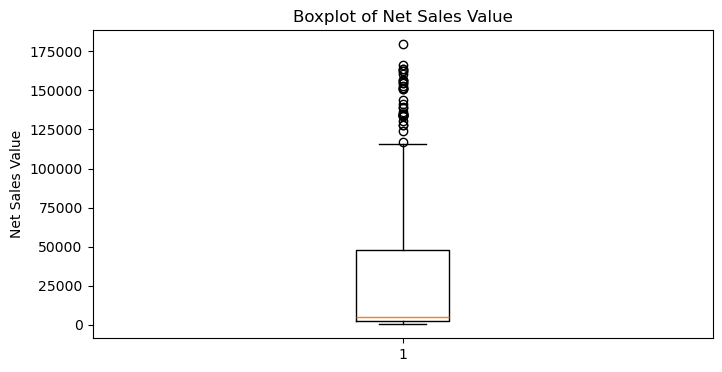

In [51]:
#Box plot for numerical variables to identify outliers and the interquartile range. 
for column in numeric:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

## Interpretation of Box Plot

**Volume**
- Most sales are between 1–6 units.
- Outliers: large orders (up to 31 units).
- Indicates normal small sales with some bulk purchases.

**Avg Price**
- Many products are low–mid price.
- Some very expensive items (~60k) are extreme outliers.
- Product mix includes both budget and premium models.

**Total Sales Value**
- Typical sales are much smaller than a few very large transactions.
- Outliers: very high-value sales (>180k).
- Distribution is highly right-skewed.

**Discount Rate (%)**
- Most discounts fall between 10%–18%.
- Outliers: a few transactions with unusually low/high discounts.
- Discounts are generally stable, with some special cases.

**Discount Amount**
- Most discounts are small (<5k).
- Outliers: large discounts (>20k).
- Caused by big-ticket sales or high-volume orders.

**Net Sales Value**
- Follows same pattern as Total Sales Value.
- Strong right skew with a few extremely high values.
- Some transactions dominate total revenue.

In [53]:
categorical=df.select_dtypes(include=['object'])
categorical

,Date,Day,SKU,City,BU,Brand,Model
0,01-04-2021,Thursday,M01,C,Mobiles,RealU,RU-10
1,01-04-2021,Thursday,M02,C,Mobiles,RealU,RU-9 Plus
2,01-04-2021,Thursday,M03,C,Mobiles,YouM,YM-99
3,01-04-2021,Thursday,M04,C,Mobiles,YouM,YM-99 Plus
4,01-04-2021,Thursday,M05,C,Mobiles,YouM,YM-98
...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,Lifestyle,Jeera,M-Casuals
446,15-04-2021,Thursday,L07,C,Lifestyle,Viva,W-Western
447,15-04-2021,Thursday,L08,C,Lifestyle,Viva,W-Lounge
448,15-04-2021,Thursday,L09,C,Lifestyle,Jeera,M-Formals


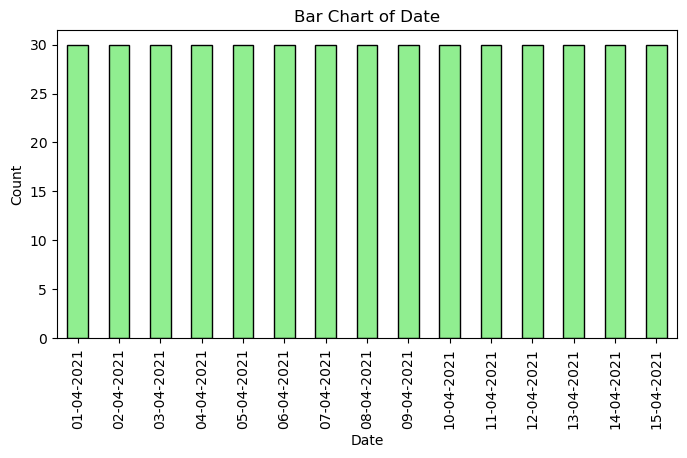

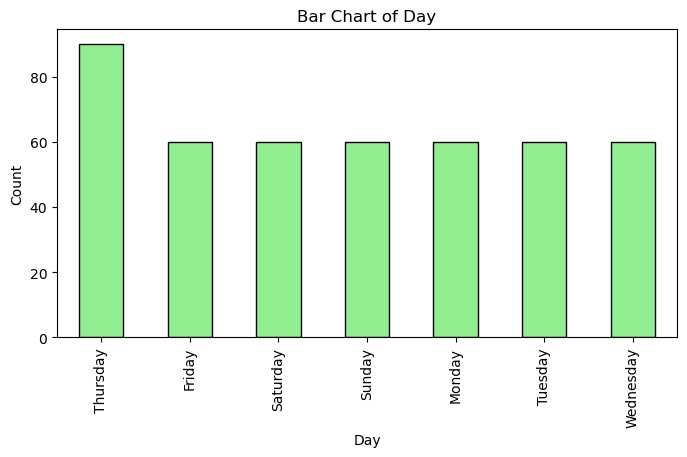

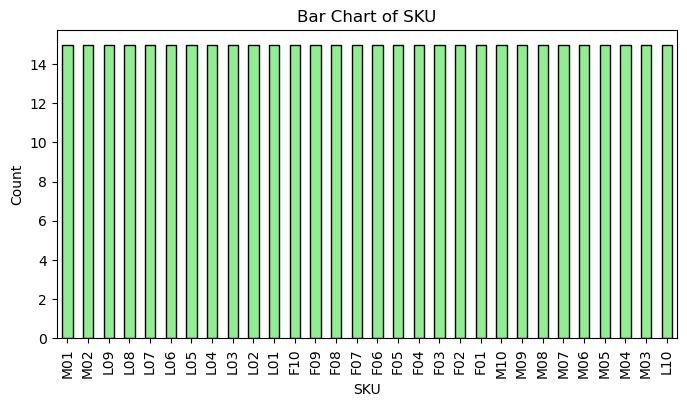

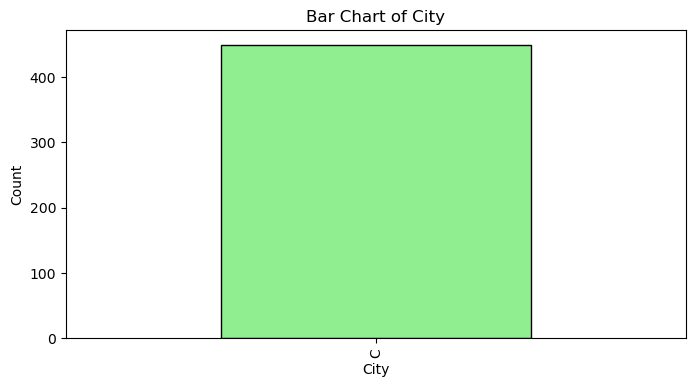

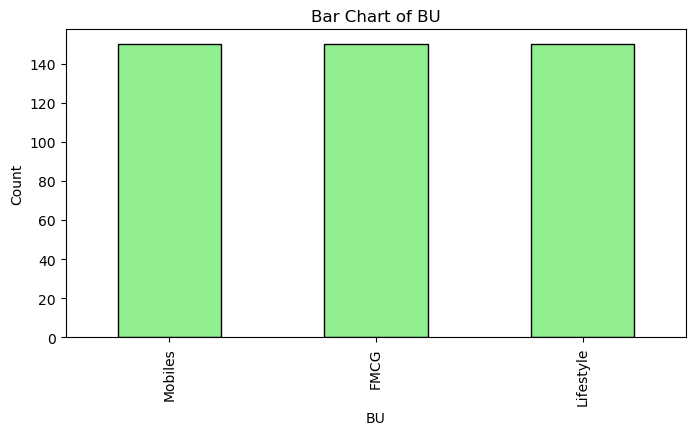

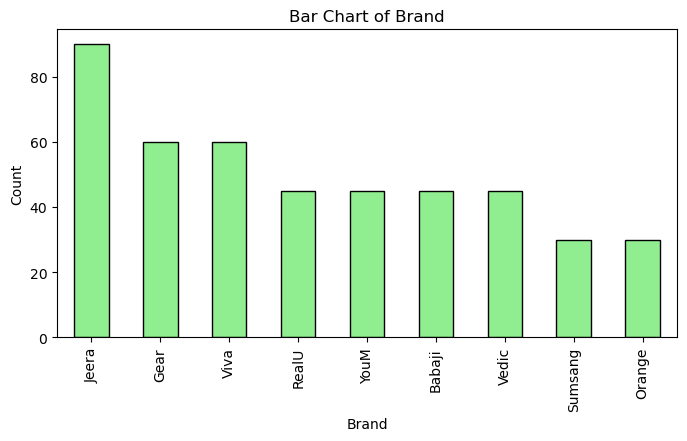

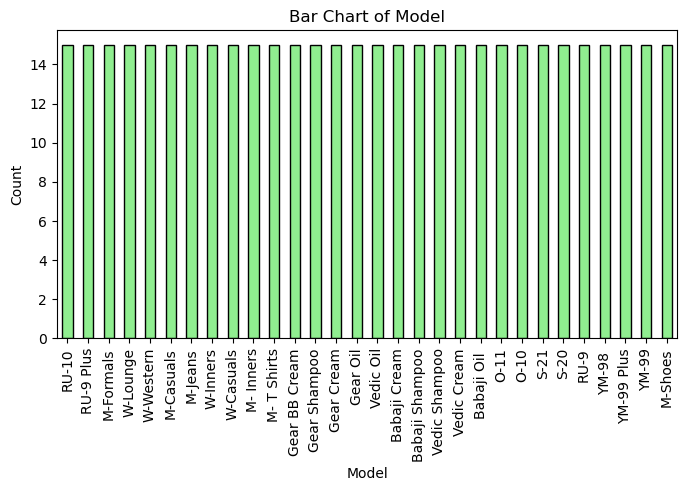

In [54]:
#Bar Chart Analysis for Categorical Column
for column in categorical:
    plt.figure(figsize=(8,4))
    df[column].value_counts().plot(kind="bar", color="lightgreen", edgecolor="black")
    plt.title(f"Bar Chart of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

## Interpretation of Bar Chart

**Date**
- Each date has entries; distribution is fairly uniform.
- Data is spread across multiple days without gaps.

**Day**
- All weekdays represented.
- Slightly more sales on some days (like Thursday).
- Sales activity is consistent across the week.

**SKU**
- Many unique SKUs.
- Some SKUs dominate, others rare.
- Inventory is diverse, but not all SKUs sell equally.

**City**
- Few cities in dataset.
- Some cities have more transactions than others.
-  Sales are concentrated in specific locations.

**BU (Business Unit)**
- Mostly Mobiles.
- Limited business diversity (one main BU).

**Brand**
- Two brands (e.g., RealU, YouM) dominate.
- Brand competition is between a few players.

**Model**
- High number of models.
- Some models are very popular, others rarely appear.
- Product portfolio is broad, but demand is uneven.

In [56]:
#Standardization of Numerical Variables

### Concept of standardization

Standardization is a data preprocessing technique used to rescale numerical features so that they have:

Mean = 0

Standard deviation = 1

It transforms the original data into a standard scale, often called a z-score.

### Why standardization is required

- Brings Features to a Common Scale

- Algorithms like KNN, SVM, Logistic Regression, Gradient Descent-based models perform better on standardized data.

- Handles Outliers Better Than Min-Max Scaling (Sometimes)

- Models with L1 or L2 regularization (like Ridge or Lasso regression) require features to be on a similar scale.

In [57]:
print(df.head())

         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  


In [59]:
numeric

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...
445,2,1300,2600,15.475687,402.367873,2197.632127
446,6,2600,15600,17.057027,2660.896242,12939.103758
447,2,1600,3200,18.965550,606.897606,2593.102394
448,3,1900,5700,16.793014,957.201826,4742.798174


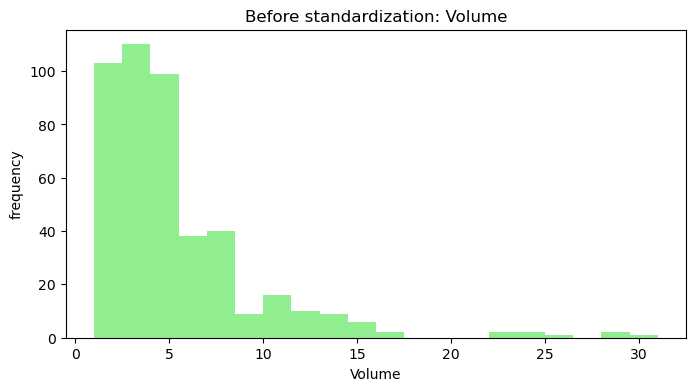

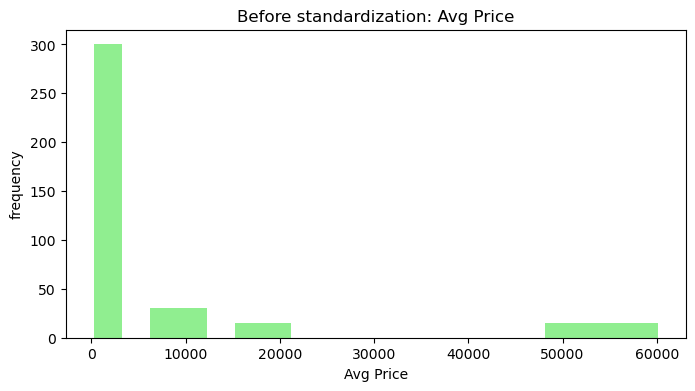

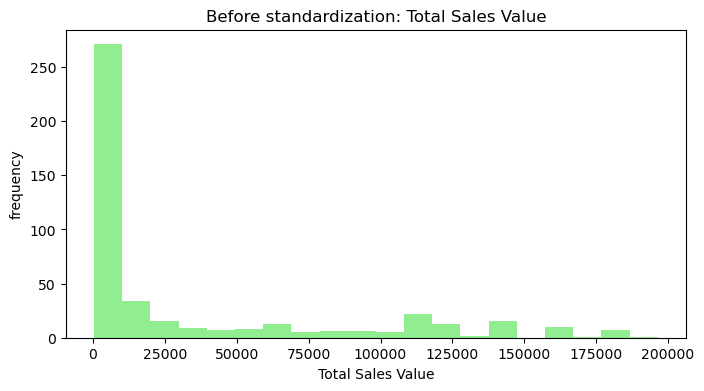

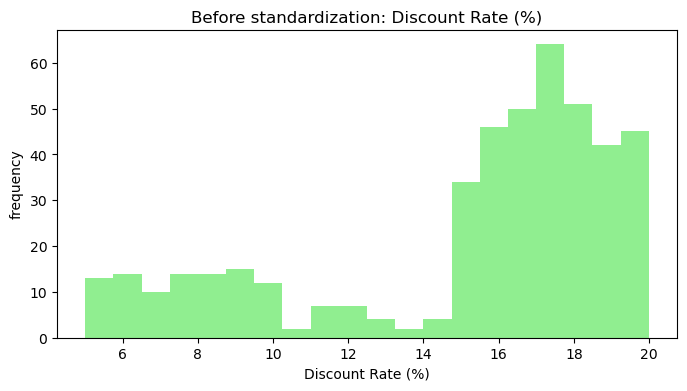

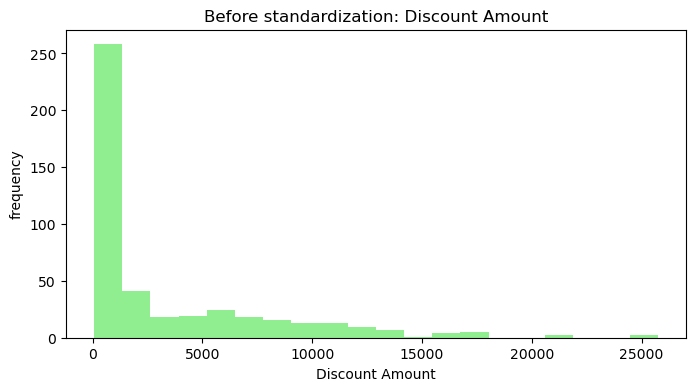

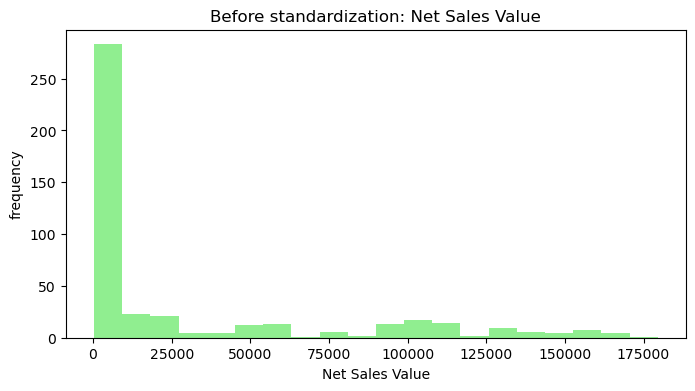

In [60]:
#before standardization
for column in numeric:
    plt.figure(figsize=(8,4))
    plt.hist(df[column],bins=20,color='lightgreen')
    plt.title(f"Before standardization: {column}")
    plt.xlabel(column)
    plt.ylabel("frequency")

In [61]:
from sklearn.preprocessing import StandardScaler

In [68]:
#Standardization
scaler=StandardScaler()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_standardized=df.copy()
df_standardized[numeric_cols]=scaler.fit_transform(df[numeric_cols])

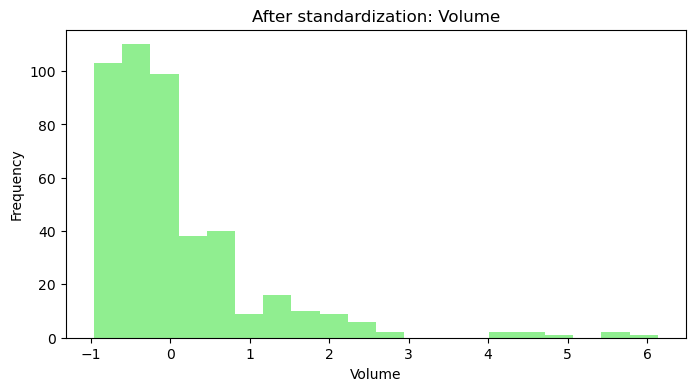

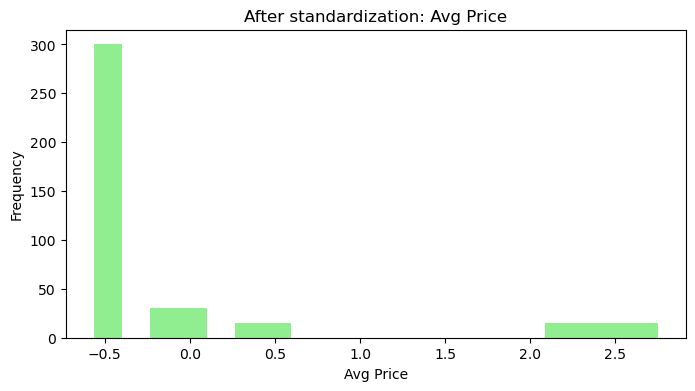

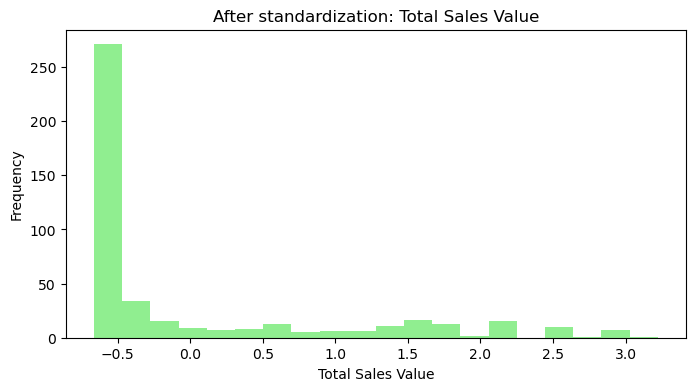

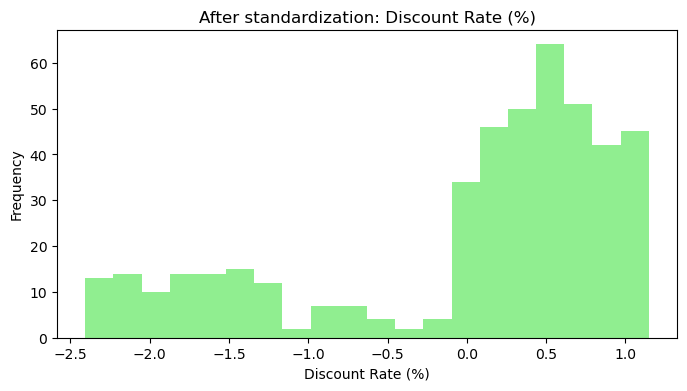

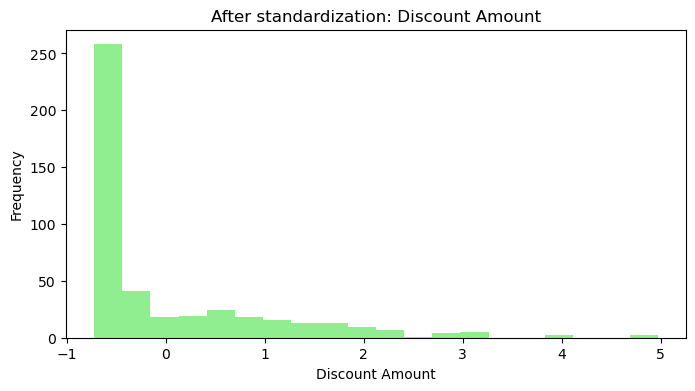

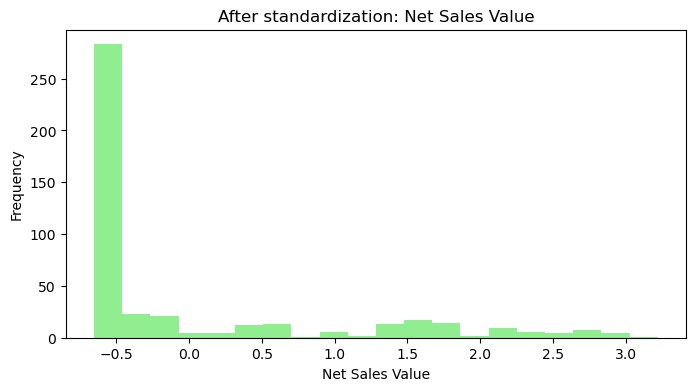

In [86]:
#After Standardization

for column in numeric:
    plt.figure(figsize=(8,4))
    plt.hist(df_standardized[column],bins=20,color="lightgreen")
    plt.title(f"After standardization: {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
#Comparison of dataseets before and after standardization

In [88]:
print(df_standardized.head())#After standardization

         Date       Day  SKU City    Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C  2.350029  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C  1.167129  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C  0.457388  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C  0.220808  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C -0.488932  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0   0.091173           2.925721          -0.830289         3.952816   
1  -0.019570           1.330995          -0.852661         1.849014   
2   0.312659           1.562775          -1.351631         1.622995   
3   0.534146           1.719276          -1.949723         1.113807   
4  -0.130313          -0.188452           0.673739         0.227852   

   Net Sales Value  
0         2.804756  
1         1.271026  
2         1.545675  
3         1.765810  
4        -0.22759

In [90]:
print(df.head())#Before Standardization

         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  


In [92]:
#Conversion of categorical data into dummy variables

### Need for converting categorical data into dummy variables

**Machine Learning Models Need Numbers**
- Most algorithms cannot work directly with text or categorical data.
- One-hot encoding converts categories into numerical format.

**Avoids False Ordinal Relationships**
- Assigning numbers to categories may imply an order that doesn’t exist.
- One-hot encoding treats each category independently.

**Improves Model Interpretability**
- Each dummy variable shows the presence (1) or absence (0) of a category.
- Model coefficients become easier to understand.

**Enables Distance-Based Calculations**
- Algorithms like KNN or K-Means use distances, which require numeric values.
- Supports Feature Engineering
- Makes it easy to create interactions between categorical variables.

**Prevents Data Misinterpretation**
- Ensures the model doesn’t assume any unintended relationship between categories.

In [100]:
categorical_cols = df.select_dtypes(include=['object']).columns

# One-Hot Encoding
df_encoded = pd.get_dummies(df_standardized, columns=categorical_cols, drop_first=True)

print("\nTransformed Dataset (after one-hot encoding):")
print(df_encoded.head())



Transformed Dataset (after one-hot encoding):
     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0  2.350029   0.091173           2.925721          -0.830289         3.952816   
1  1.167129  -0.019570           1.330995          -0.852661         1.849014   
2  0.457388   0.312659           1.562775          -1.351631         1.622995   
3  0.220808   0.534146           1.719276          -1.949723         1.113807   
4 -0.488932  -0.130313          -0.188452           0.673739         0.227852   

   Net Sales Value  Date_02-04-2021  Date_03-04-2021  Date_04-04-2021  \
0         2.804756            False            False            False   
1         1.271026            False            False            False   
2         1.545675            False            False            False   
3         1.765810            False            False            False   
4        -0.227595            False            False            False   

   Date_05-04-2021  ...  Mo

In [106]:
df_encoded=df_encoded.astype(int)
print(df_encoded.head())

   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0       2          0                  2                  0                3   
1       1          0                  1                  0                1   
2       0          0                  1                 -1                1   
3       0          0                  1                 -1                1   
4       0          0                  0                  0                0   

   Net Sales Value  Date_02-04-2021  Date_03-04-2021  Date_04-04-2021  \
0                2                0                0                0   
1                1                0                0                0   
2                1                0                0                0   
3                1                0                0                0   
4                0                0                0                0   

   Date_05-04-2021  ...  Model_Vedic Cream  Model_Vedic Oil  \
0                0  ...

## Conclusion

**The descriptive analytics and data visualizations provided valuable insights into the sales dataset.**

- Statistical analysis of numerical variables such as Volume, Avg Price, Total Sales Value, Discount Rate (%), Discount Amount, and Net Sales Value revealed key patterns in sales performance.
- The mean and median values helped understand central tendencies, while the standard deviation highlighted variability in prices and sales across different products and brands. For instance, high variability in total sales and discount amounts indicated diverse sales strategies or product performances across categories.
- The histograms showed that most numerical variables were right-skewed, suggesting that a majority of products or transactions occur at lower sales volumes or values, with a few high-value outliers.
- Boxplots further confirmed the presence of these outliers, which may correspond to premium models or special discount events.
- The bar charts for categorical variables like City, Brand, and Business Unit (BU) revealed differences in sales concentration — some cities or brands dominated sales, reflecting market preference patterns.

**Data preprocessing played a crucial role in preparing the dataset for modeling:**

- Standardization (using z-score normalization) ensured that numerical variables such as prices and sales values were on a uniform scale, making them more comparable and improving the performance of analytical or machine learning models.
- One-hot encoding of categorical columns such as City, Brand, and Model transformed qualitative data into numerical format, enabling algorithms to process categorical distinctions effectively.

Overall, these steps ensured that the dataset was clean, consistent, and ready for advanced analytics or predictive modeling. The combination of descriptive analysis, visualization, and preprocessing provided a strong foundation for uncovering data-driven business insights and enhancing model accuracy in future analyses.